<a href="https://colab.research.google.com/github/Nexus297/stroke-rough-draft/blob/main/stroke_eda_preprocessing_rough_draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [25]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) #Remove warning

In [26]:
# loaded this here for later
import imblearn
from imblearn.pipeline import Pipeline as ImbPipeline

In [27]:
def load_and_clean_data(filepath):
    df = pd.read_csv(filepath)

    # ID is useless for the model, dropping it
    if 'id' in df.columns:
        df = df.drop(columns=['id'])

    # N/A strings in kaggle data messing up the dtype. forcing numeric.
    if 'bmi' in df.columns:
        df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')

    return df

In [28]:
def perform_eda(df):
    print("--- Quick EDA ---")

    # Check imbalance severity (~95/5)
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='stroke')
    plt.title('Stroke vs. No Stroke Imbalance')
    plt.show()

    print("Class ratio:\n", df['stroke'].value_counts(normalize=True) * 100)

    # Checking missing values for IterativeImputer later
    print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

In [29]:
def build_preprocessing_pipeline():
    numeric_features = ['age', 'avg_glucose_level', 'bmi']
    categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

    # BMI has missing values, using IterativeImputer before scaling
    numeric_transformer = Pipeline(steps=[
        ('imputer', IterativeImputer(max_iter=10, random_state=42)),
        ('scaler', StandardScaler())
    ])

    # Categorical - drop first to avoid dummy trap.
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='error'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop' # safety net to drop anything I forgot
    )

    return preprocessor

In [30]:
def get_stratified_splits(df, target_col='stroke', test_size=0.2):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    #needed otherwise test set might have zero minority cases
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=42
    )

    return X_train, X_test, y_train, y_test

In [31]:
def perform_extended_eda(df):
    print("\n--- Extended EDA ---")
    sns.set_theme(style="whitegrid")

    # 1. Correlation Matrix
    plt.figure(figsize=(8, 6))
    corr_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
    sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()
    # Note: Age correlates highest. Watch BMI (0.04) - jump post-SMOTE = rank shift proof.

    # 2. Boxplots (Outliers)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, col in enumerate(['age', 'avg_glucose_level', 'bmi']):
        sns.boxplot(data=df, x='stroke', y=col, ax=axes[i], palette='Set2')
        axes[i].set_title(col)
    plt.tight_layout()
    plt.show()
    # Note: Glucose has massive outliers in stroke=1. BMI overlaps heavily. Watch ADASYN here.

    # 3. Categorical Proportions
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for i, col in enumerate(['smoking_status', 'work_type']):
        prop_df = df.groupby(col)['stroke'].value_counts(normalize=True).rename('prop').reset_index()
        sns.barplot(data=prop_df[prop_df['stroke'] == 1], x=col, y='prop', ax=axes[i], palette='magma')
        axes[i].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    # Note: Proportions matter more than counts. Trends here likely confounded by age.

    # 4. Age vs Glucose Scatter
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x='age', y='avg_glucose_level', hue='stroke', style='stroke', alpha=0.6)
    plt.title("Age vs Avg Glucose")
    plt.show()
    # Note: Danger zone is Age > 50 & Glucose > 150. Will SMOTENC generate fakes outside this cluster?

--- Quick EDA ---


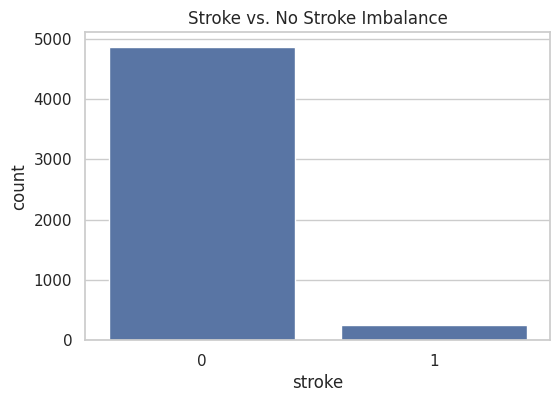

Class ratio:
 stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

Missing values:
 bmi    201
dtype: int64

--- Extended EDA ---


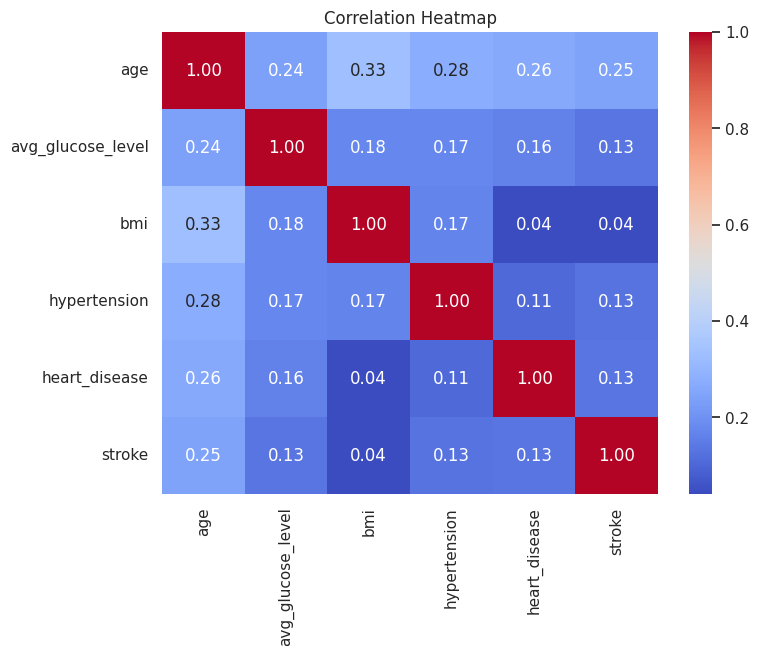

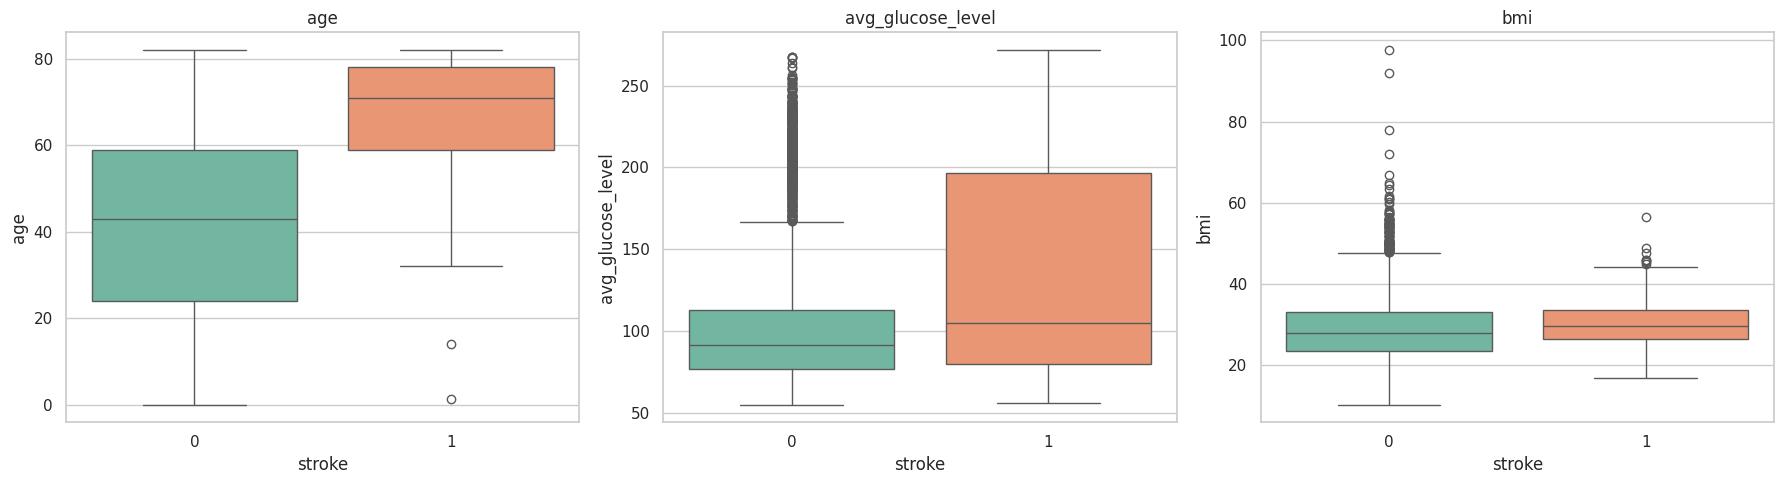

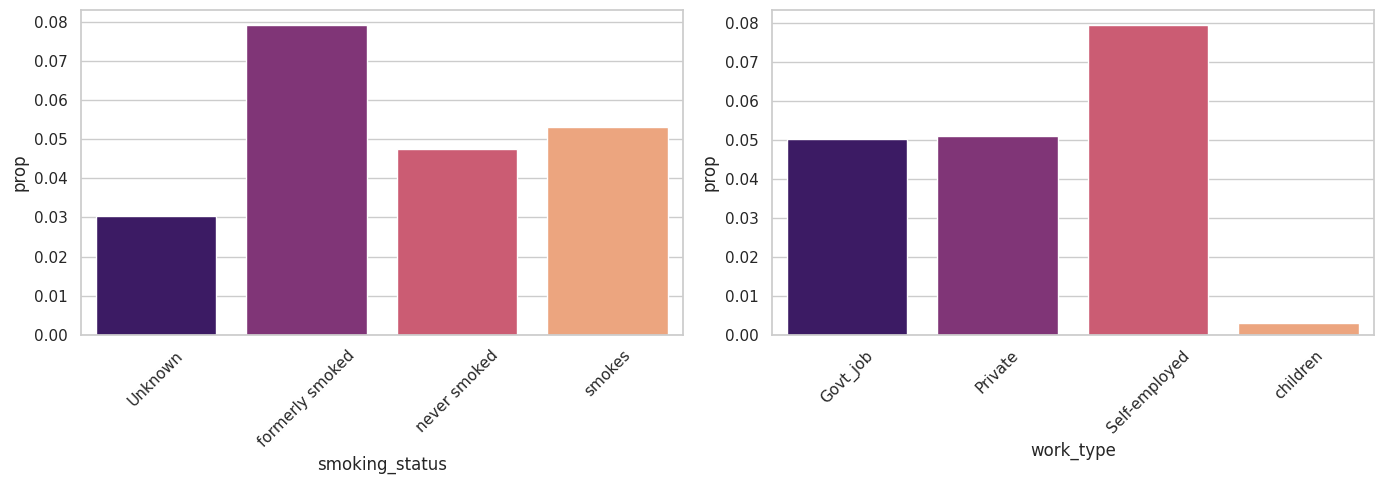

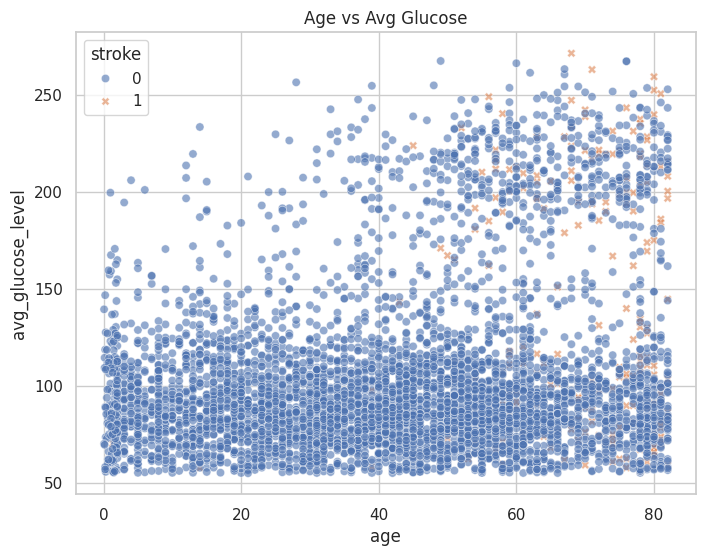

Preprocessing done. Shape: (4088, 14)


In [32]:
#Main
if __name__ == "__main__":
    FILE_PATH = '/content/healthcare-dataset-stroke-data.csv'

    # 1. Setup
    stroke_df = load_and_clean_data(FILE_PATH)

    # 2. EDA
    perform_eda(stroke_df)
    perform_extended_eda(stroke_df)

    # 3. Split
    X_train, X_test, y_train, y_test = get_stratified_splits(stroke_df)

    # 4. Preprocess
    preprocessor = build_preprocessing_pipeline()
    X_train_processed = preprocessor.fit_transform(X_train)

    print("Preprocessing done. Shape:", X_train_processed.shape)